In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

%matplotlib inline

X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

X

array([[-7.36706647,  5.66904397],
       [-5.90549974, -6.78149923],
       [ 2.10700999, -6.54902972],
       ...,
       [-0.77176004, -6.82749383],
       [-7.52106628, -9.09796802],
       [-0.69038125, -5.67460705]], shape=(1000, 2))

In [2]:
y

array([2, 0, 1, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 2,
       1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 0, 2, 0, 0, 1, 0, 1, 2, 2, 0, 1, 2,
       1, 0, 1, 2, 2, 2, 1, 1, 2, 1, 0, 0, 2, 0, 1, 0, 2, 1, 2, 2, 1, 2,
       1, 0, 2, 2, 2, 1, 2, 2, 2, 0, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2,
       0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 2, 0, 1, 0, 1,
       2, 0, 1, 2, 0, 2, 2, 0, 0, 0, 1, 1, 2, 2, 0, 1, 2, 1, 2, 1, 0, 0,
       1, 1, 1, 1, 1, 2, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 2, 1, 1, 2, 2, 1,
       0, 0, 1, 2, 2, 1, 2, 2, 1, 0, 0, 1, 0, 2, 2, 2, 2, 0, 2, 1, 1, 1,
       1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 0, 1, 0, 0,
       1, 0, 2, 2, 0, 2, 2, 1, 2, 2, 1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 0, 2,
       2, 0, 2, 1, 0, 1, 2, 2, 0, 2, 1, 0, 2, 1, 0, 1, 2, 0, 1, 0, 2, 0,
       1, 2, 0, 1, 1, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 2, 1, 1, 2, 0, 0, 1,
       0, 1, 2, 1, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 2, 2, 1, 2, 0, 0, 1,
       0, 1, 0, 2, 0, 1, 2, 1, 2, 2, 2, 1, 0, 2, 0,

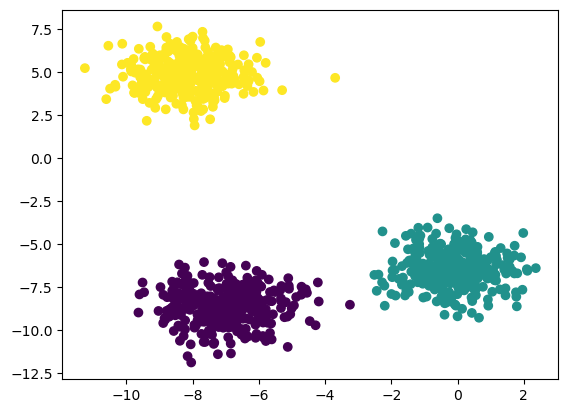

In [17]:
plt.scatter(X[:, 0], X[:, 1],c=y)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.cluster import KMeans

# Elbow method to select K value
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\Ashima\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Ashima\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Ashima\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Ashima\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

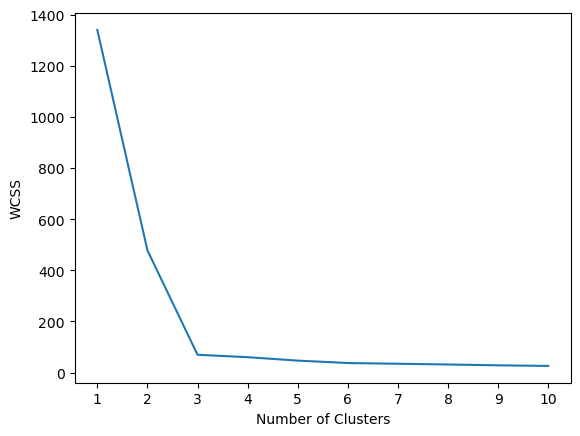

In [9]:
plt.plot(range(1, 11), wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, init="k-means++")

kmeans.fit_predict(X_train_scaled)

C:\Users\Ashima\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([0, 2, 0, 2, 1, 0, 0, 2, 2, 0, 2, 0, 1, 0, 1, 2, 0, 2, 1, 0, 0, 2,
       2, 1, 0, 2, 2, 2, 0, 0, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 1, 0, 2, 0,
       1, 0, 0, 1, 1, 2, 0, 2, 0, 2, 1, 2, 1, 0, 1, 0, 2, 2, 0, 2, 2, 1,
       0, 0, 1, 0, 1, 0, 2, 2, 0, 2, 0, 1, 0, 2, 0, 2, 2, 2, 1, 1, 0, 2,
       2, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 1, 2, 0, 2, 1, 0, 2, 1, 1,
       0, 0, 0, 2, 2, 2, 2, 0, 0, 2, 0, 1, 0, 2, 1, 0, 1, 2, 2, 0, 1, 1,
       0, 2, 1, 0, 2, 2, 2, 1, 2, 0, 2, 1, 0, 2, 0, 2, 0, 1, 1, 0, 0, 2,
       0, 1, 0, 1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 0, 0, 0, 2, 2, 2,
       1, 0, 2, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 2, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 2, 2, 1, 2, 0, 2, 0, 0, 2, 2, 1, 1, 2, 0, 2, 2, 2, 1,
       1, 0, 0, 2, 1, 1, 1, 2, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 2, 1, 0, 2,
       2, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 2, 1, 0, 0, 1, 0, 0, 0, 0, 2, 2,
       2, 2, 0, 1, 2, 2, 0, 0, 2, 1, 0, 2, 0, 1, 0, 1, 1, 0, 1, 1, 2, 2,
       1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 2, 0,

In [11]:
y_pred = kmeans.predict(X_test_scaled)

In [12]:
y_pred = kmeans.predict(X_test_scaled)

In [13]:
y_pred

array([2, 1, 0, 2, 1, 2, 2, 1, 0, 0, 1, 0, 0, 2, 1, 2, 1, 1, 2, 2, 0, 0,
       0, 2, 2, 0, 0, 2, 0, 0, 1, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 1, 1, 0,
       1, 0, 0, 2, 2, 1, 1, 2, 2, 0, 0, 0, 2, 1, 2, 2, 1, 2, 2, 2, 1, 1,
       0, 1, 1, 0, 0, 2, 2, 2, 1, 1, 2, 1, 1, 0, 2, 0, 1, 2, 2, 1, 2, 2,
       1, 1, 0, 1, 0, 2, 0, 0, 1, 2, 1, 1, 0, 0, 1, 0, 2, 0, 1, 1, 1, 2,
       0, 0, 2, 0, 1, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 2, 0, 1, 2, 2, 2, 1,
       0, 2, 0, 2, 0, 0, 0, 1, 0, 1, 1, 0, 2, 2, 0, 2, 0, 0, 1, 1, 2, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 1, 0, 2, 0,
       0, 0, 1, 2, 0, 2, 1, 2, 0, 1, 0, 2, 2, 0, 2, 0, 1, 2, 0, 0, 1, 0,
       0, 0, 0, 2, 2, 0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       2, 0, 2, 1, 0, 0, 2, 0, 1, 0, 1, 0, 1, 2, 1, 1, 2, 0, 0, 1, 2, 1,
       2, 2, 2, 0, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 0, 2, 1, 0, 1, 0, 1, 1,
       2, 0, 0, 0, 1, 2, 1, 0, 1, 1, 1, 0, 2, 1, 0, 0, 0, 2, 2, 2, 1, 2,
       2, 1, 1, 2, 1, 2, 2, 0, 0, 2, 2, 1, 0, 2, 2,

ValueError: 'c' argument has 1000 elements, which is inconsistent with 'x' and 'y' with size 330.

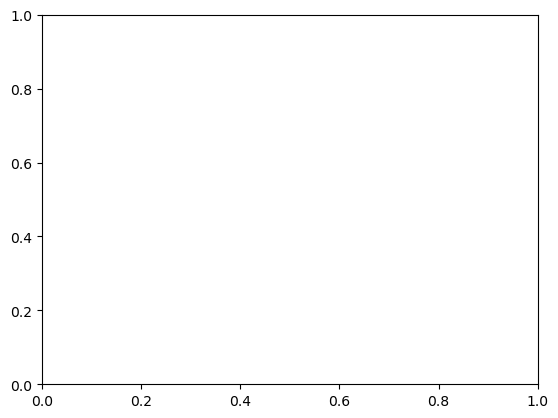

In [14]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y)

In [15]:
kmeans = KMeans(n_clusters=3, init="k-means++")

kmeans.fit_predict(X_train_scaled)

C:\Users\Ashima\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([0, 2, 0, 2, 1, 0, 0, 2, 2, 0, 2, 0, 1, 0, 1, 2, 0, 2, 1, 0, 0, 2,
       2, 1, 0, 2, 2, 2, 0, 0, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 1, 0, 2, 0,
       1, 0, 0, 1, 1, 2, 0, 2, 0, 2, 1, 2, 1, 0, 1, 0, 2, 2, 0, 2, 2, 1,
       0, 0, 1, 0, 1, 0, 2, 2, 0, 2, 0, 1, 0, 2, 0, 2, 2, 2, 1, 1, 0, 2,
       2, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 1, 2, 0, 2, 1, 0, 2, 1, 1,
       0, 0, 0, 2, 2, 2, 2, 0, 0, 2, 0, 1, 0, 2, 1, 0, 1, 2, 2, 0, 1, 1,
       0, 2, 1, 0, 2, 2, 2, 1, 2, 0, 2, 1, 0, 2, 0, 2, 0, 1, 1, 0, 0, 2,
       0, 1, 0, 1, 1, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 0, 0, 0, 2, 2, 2,
       1, 0, 2, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 2, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 2, 2, 1, 2, 0, 2, 0, 0, 2, 2, 1, 1, 2, 0, 2, 2, 2, 1,
       1, 0, 0, 2, 1, 1, 1, 2, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 2, 1, 0, 2,
       2, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 2, 1, 0, 0, 1, 0, 0, 0, 0, 2, 2,
       2, 2, 0, 1, 2, 2, 0, 0, 2, 1, 0, 2, 0, 1, 0, 1, 1, 0, 1, 1, 2, 2,
       1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 2, 2, 2, 0,